# Projeto de Inteligência Artificial — Statlog (German Credit Data)

**Base de dados:** Statlog (German Credit Data) — UCI Machine Learning Repository  
**Objetivo:** construir e avaliar modelos de classificação para prever risco de crédito.

A base possui 1000 registros, 20 atributos de entrada e uma variável alvo que classifica clientes como:

- `1` = bom risco de crédito
- `2` = mau risco de crédito

Além das métricas tradicionais, este projeto considera a matriz de custo sugerida pela própria base:

- Classificar um cliente bom como mau tem custo `1`.
- Classificar um cliente mau como bom tem custo `5`.

Isso é importante porque, em crédito, liberar crédito para um cliente de alto risco pode gerar prejuízo maior do que negar crédito a um cliente bom.

## 1. Importação das bibliotecas

Nesta etapa importamos bibliotecas para manipulação dos dados, visualização, pré-processamento, treinamento de modelos e avaliação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 2. Carregamento da base de dados

O arquivo original `german.data` contém atributos categóricos e numéricos. O código abaixo tenta carregar diretamente da UCI. Caso esteja sem internet, faça o download manual do arquivo `german.data` e coloque-o na mesma pasta deste notebook.

Link da base: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

In [2]:
colunas = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "present_residence",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "class"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

try:
    df = pd.read_csv(url, sep=" ", header=None, names=colunas)
    print("Base carregada diretamente da UCI.")
except Exception as e:
    print("Não foi possível carregar pela internet. Tentando carregar arquivo local 'german.data'.")
    df = pd.read_csv("german.data", sep=" ", header=None, names=colunas)

print("Dimensões da base:", df.shape)
df.head()

Base carregada diretamente da UCI.
Dimensões da base: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 3. Dicionário simplificado das variáveis

A base utiliza códigos como `A11`, `A12`, `A30`, `A31`, etc. Para facilitar a análise, o projeto trabalha com os códigos originais, pois os modelos conseguem lidar com eles após a etapa de codificação categórica.

Variáveis principais:

- `checking_account`: situação da conta corrente
- `duration`: duração do crédito em meses
- `credit_history`: histórico de crédito
- `purpose`: finalidade do crédito
- `credit_amount`: valor do crédito
- `savings_account`: conta poupança/títulos
- `employment_since`: tempo de emprego atual
- `installment_rate`: taxa de parcela em relação à renda disponível
- `age`: idade
- `housing`: tipo de moradia
- `class`: classe alvo, sendo `1` bom risco e `2` mau risco

## 4. Análise inicial dos dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_account,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_since,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status_sex,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
checking_account           0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
class                      0
dtype: int64


Distribuição da variável alvo original:
class
1    700
2    300
Name: count, dtype: int64


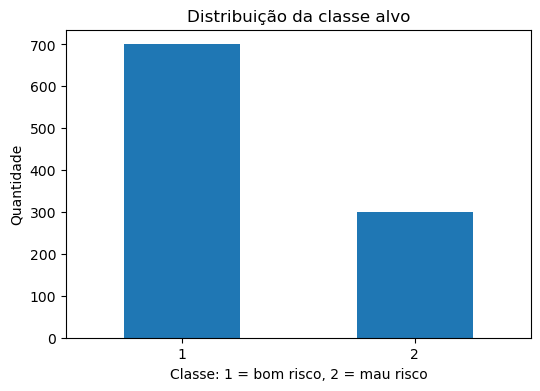

In [6]:
print("Distribuição da variável alvo original:")
print(df["class"].value_counts())

plt.figure(figsize=(6,4))
df["class"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da classe alvo")
plt.xlabel("Classe: 1 = bom risco, 2 = mau risco")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

## 5. Pré-processamento da variável alvo

Para facilitar a interpretação dos modelos, vamos converter a variável alvo:

- `0` = bom risco de crédito
- `1` = mau risco de crédito

Assim, a classe positiva será o cliente de maior risco.

In [7]:
df_modelo = df.copy()
df_modelo["target"] = df_modelo["class"].map({1: 0, 2: 1})
df_modelo = df_modelo.drop(columns=["class"])

print(df_modelo["target"].value_counts())
print(df_modelo["target"].value_counts(normalize=True))

target
0    700
1    300
Name: count, dtype: int64
target
0    0.7
1    0.3
Name: proportion, dtype: float64


## 6. Análise exploratória simples

Vamos observar algumas relações entre atributos numéricos e a classe de risco.

<Figure size 600x400 with 0 Axes>

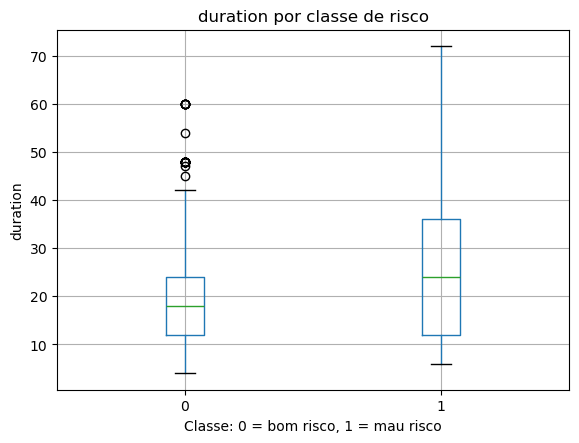

<Figure size 600x400 with 0 Axes>

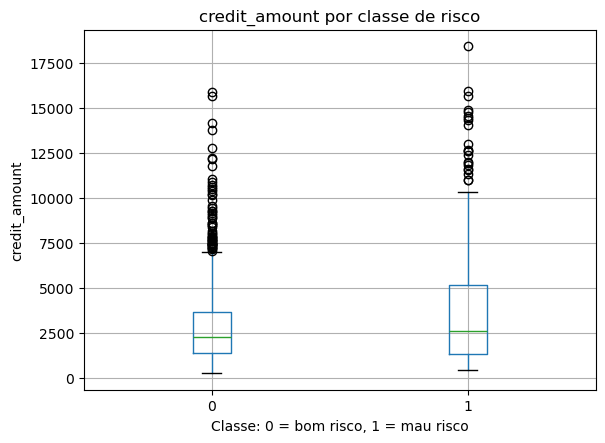

<Figure size 600x400 with 0 Axes>

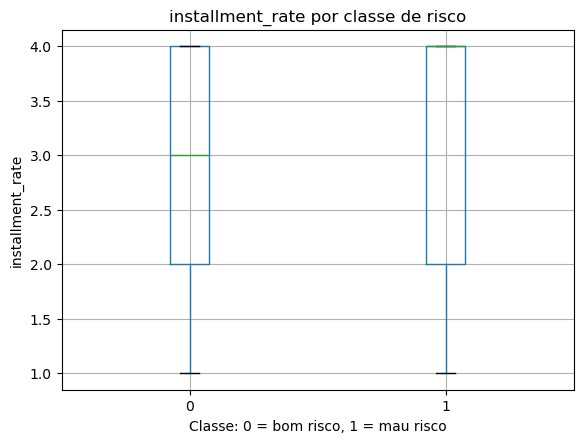

<Figure size 600x400 with 0 Axes>

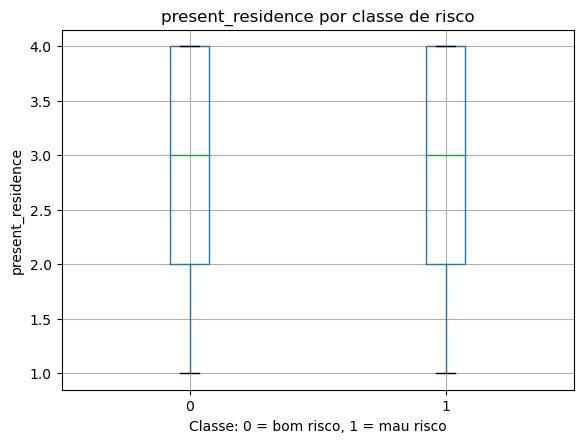

<Figure size 600x400 with 0 Axes>

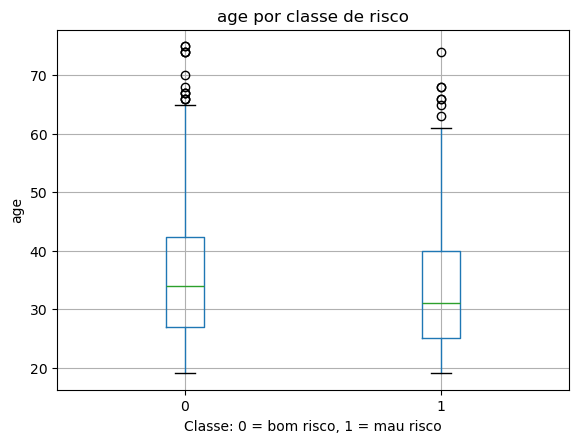

<Figure size 600x400 with 0 Axes>

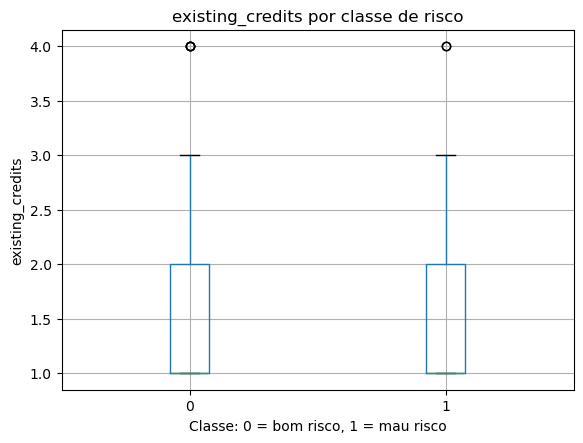

<Figure size 600x400 with 0 Axes>

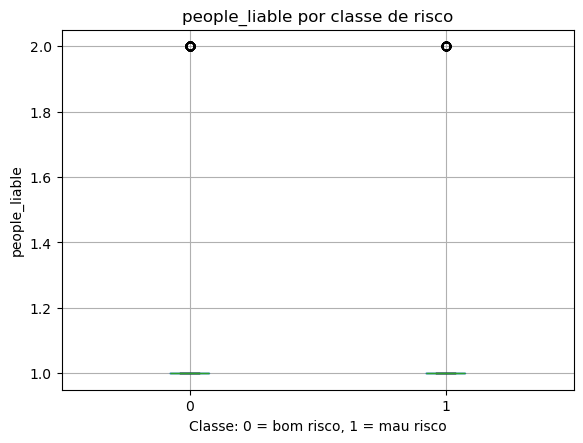

In [8]:
variaveis_numericas = ["duration", "credit_amount", "installment_rate", "present_residence", "age", "existing_credits", "people_liable"]

for col in variaveis_numericas:
    plt.figure(figsize=(6,4))
    df_modelo.boxplot(column=col, by="target")
    plt.title(f"{col} por classe de risco")
    plt.suptitle("")
    plt.xlabel("Classe: 0 = bom risco, 1 = mau risco")
    plt.ylabel(col)
    plt.show()

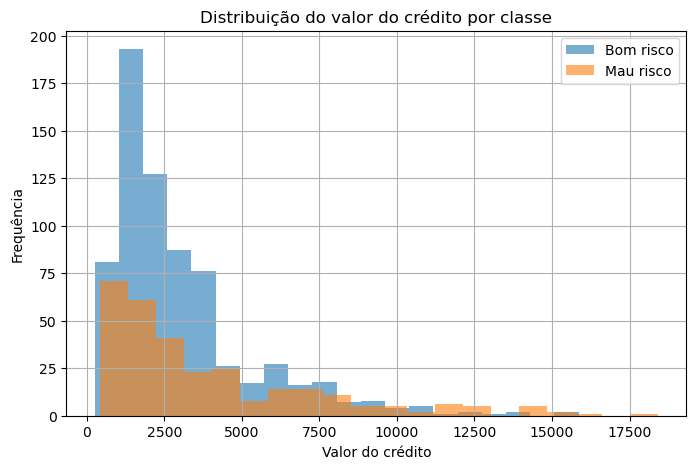

In [9]:
plt.figure(figsize=(8,5))
df_modelo.groupby("target")["credit_amount"].hist(alpha=0.6, bins=20)
plt.title("Distribuição do valor do crédito por classe")
plt.xlabel("Valor do crédito")
plt.ylabel("Frequência")
plt.legend(["Bom risco", "Mau risco"])
plt.show()

## 7. Separação entre atributos e alvo

In [10]:
X = df_modelo.drop(columns=["target"])
y = df_modelo["target"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Colunas categóricas:", categorical_cols)
print("Colunas numéricas:", numeric_cols)

Colunas categóricas: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Colunas numéricas: ['duration', 'credit_amount', 'installment_rate', 'present_residence', 'age', 'existing_credits', 'people_liable']


## 8. Separação em treino e teste

Usaremos 70% dos dados para treino e 30% para teste. A opção `stratify=y` mantém a proporção das classes nas duas amostras.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Distribuição no treino:")
print(y_train.value_counts(normalize=True))
print("Distribuição no teste:")
print(y_test.value_counts(normalize=True))

Treino: (700, 20) Teste: (300, 20)
Distribuição no treino:
target
0    0.7
1    0.3
Name: proportion, dtype: float64
Distribuição no teste:
target
0    0.7
1    0.3
Name: proportion, dtype: float64


## 9. Pipeline de pré-processamento

As variáveis categóricas serão transformadas com `OneHotEncoder`. As variáveis numéricas serão padronizadas com `StandardScaler`.

In [12]:
preprocessamento = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

## 10. Função de avaliação dos modelos

Além das métricas tradicionais, criaremos uma função para calcular o custo do erro conforme a matriz de custo da base:

- Real bom, previsto mau: custo 1
- Real mau, previsto bom: custo 5

In [13]:
def calcular_custo(y_real, y_pred):
    custo = 0
    for real, pred in zip(y_real, y_pred):
        if real == 0 and pred == 1:
            custo += 1
        elif real == 1 and pred == 0:
            custo += 5
    return custo


def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    matriz = confusion_matrix(y_test, y_pred)
    custo = calcular_custo(y_test, y_pred)

    resultados = {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc,
        "Custo": custo
    }

    print("="*70)
    print(nome)
    print("="*70)
    print("Matriz de confusão:")
    print(matriz)
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred, target_names=["Bom risco", "Mau risco"]))
    print("Custo total:", custo)

    return resultados

## 11. Modelo base: Dummy Classifier

O Dummy Classifier serve como referência. Ele não aprende padrões complexos; apenas usa uma estratégia simples. Os modelos de IA devem superar esse resultado.

In [14]:
modelo_dummy = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("classificador", DummyClassifier(strategy="most_frequent"))
])

modelo_dummy.fit(X_train, y_train)
resultado_dummy = avaliar_modelo("Dummy Classifier", modelo_dummy, X_test, y_test)

Dummy Classifier
Matriz de confusão:
[[210   0]
 [ 90   0]]

Relatório de classificação:
              precision    recall  f1-score   support

   Bom risco       0.70      1.00      0.82       210
   Mau risco       0.00      0.00      0.00        90

    accuracy                           0.70       300
   macro avg       0.35      0.50      0.41       300
weighted avg       0.49      0.70      0.58       300

Custo total: 450


## 12. Modelo 1 — Regressão Logística

In [15]:
modelo_lr = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_lr.fit(X_train, y_train)
resultado_lr = avaliar_modelo("Regressão Logística", modelo_lr, X_test, y_test)

Regressão Logística
Matriz de confusão:
[[187  23]
 [ 42  48]]

Relatório de classificação:
              precision    recall  f1-score   support

   Bom risco       0.82      0.89      0.85       210
   Mau risco       0.68      0.53      0.60        90

    accuracy                           0.78       300
   macro avg       0.75      0.71      0.72       300
weighted avg       0.77      0.78      0.78       300

Custo total: 233


## 13. Modelo 2 — Árvore de Decisão

In [ ]:
modelo_dt = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("classificador", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

modelo_dt.fit(X_train, y_train)
resultado_dt = avaliar_modelo("Árvore de Decisão", modelo_dt, X_test, y_test)

## 14. Modelo 3 — Random Forest

In [ ]:
modelo_rf = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("classificador", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
])

modelo_rf.fit(X_train, y_train)
resultado_rf = avaliar_modelo("Random Forest", modelo_rf, X_test, y_test)

## 15. Modelo 4 — Gradient Boosting

In [ ]:
modelo_gb = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("classificador", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

modelo_gb.fit(X_train, y_train)
resultado_gb = avaliar_modelo("Gradient Boosting", modelo_gb, X_test, y_test)

## 16. Comparação dos modelos

In [ ]:
resultados = pd.DataFrame([
    resultado_dummy,
    resultado_lr,
    resultado_dt,
    resultado_rf,
    resultado_gb
])

resultados_ordenados = resultados.sort_values(by="Custo", ascending=True)
resultados_ordenados

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(resultados_ordenados["Modelo"], resultados_ordenados["Custo"])
plt.title("Comparação dos modelos pelo custo total")
plt.xlabel("Modelo")
plt.ylabel("Custo total")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
metricas = ["Acurácia", "Precisão", "Recall", "F1-score", "ROC-AUC"]

for metrica in metricas:
    plt.figure(figsize=(10,5))
    plt.bar(resultados["Modelo"], resultados[metrica])
    plt.title(f"Comparação dos modelos — {metrica}")
    plt.xlabel("Modelo")
    plt.ylabel(metrica)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.show()

## 17. Curva ROC dos modelos

In [ ]:
plt.figure(figsize=(8,6))

for nome, modelo in [
    ("Regressão Logística", modelo_lr),
    ("Árvore de Decisão", modelo_dt),
    ("Random Forest", modelo_rf),
    ("Gradient Boosting", modelo_gb)
]:
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, name=nome, ax=plt.gca())

plt.title("Curva ROC dos modelos")
plt.show()

## 18. Ajuste de limiar de decisão

Por padrão, muitos classificadores classificam como classe `1` quando a probabilidade é maior ou igual a `0.5`. Porém, como o erro de classificar cliente mau como bom tem custo maior, podemos testar diferentes limiares e escolher aquele que minimiza o custo.

Nesta etapa, usaremos a Regressão Logística como exemplo, mas o mesmo raciocínio pode ser aplicado a outros modelos com `predict_proba`.

In [ ]:
probs_lr = modelo_lr.predict_proba(X_test)[:, 1]

limiares = np.arange(0.05, 0.96, 0.01)
custos = []

for limiar in limiares:
    pred_limiar = (probs_lr >= limiar).astype(int)
    custos.append(calcular_custo(y_test, pred_limiar))

melhor_indice = int(np.argmin(custos))
melhor_limiar = limiares[melhor_indice]
menor_custo = custos[melhor_indice]

print("Melhor limiar:", round(melhor_limiar, 2))
print("Menor custo:", menor_custo)

plt.figure(figsize=(8,5))
plt.plot(limiares, custos)
plt.axvline(melhor_limiar, linestyle="--")
plt.title("Custo por limiar de decisão — Regressão Logística")
plt.xlabel("Limiar para classificar como mau risco")
plt.ylabel("Custo total")
plt.show()

In [ ]:
y_pred_lr_ajustado = (probs_lr >= melhor_limiar).astype(int)

print("Matriz de confusão com limiar ajustado:")
print(confusion_matrix(y_test, y_pred_lr_ajustado))
print("\nRelatório com limiar ajustado:")
print(classification_report(y_test, y_pred_lr_ajustado, target_names=["Bom risco", "Mau risco"]))
print("Custo ajustado:", calcular_custo(y_test, y_pred_lr_ajustado))

## 19. Otimização simples com GridSearchCV

Vamos fazer uma busca simples de hiperparâmetros para a Random Forest. A métrica usada no `GridSearchCV` será F1-score, mas a escolha final também considerará o custo.

In [ ]:
param_grid_rf = {
    "classificador__n_estimators": [100, 300],
    "classificador__max_depth": [None, 4, 6, 8],
    "classificador__min_samples_leaf": [1, 3, 5],
    "classificador__class_weight": [None, "balanced"]
}

pipeline_rf = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("classificador", RandomForestClassifier(random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_rf.best_params_)
print("Melhor F1 médio na validação:", grid_rf.best_score_)

resultado_rf_otimizado = avaliar_modelo("Random Forest Otimizada", grid_rf.best_estimator_, X_test, y_test)

## 20. Importância das variáveis — Random Forest otimizada

Abaixo analisamos quais variáveis tiveram maior importância para a Random Forest otimizada.

In [ ]:
melhor_rf = grid_rf.best_estimator_

preprocessador_treinado = melhor_rf.named_steps["preprocessamento"]
classificador_treinado = melhor_rf.named_steps["classificador"]

nomes_cat = preprocessador_treinado.named_transformers_["cat"].get_feature_names_out(categorical_cols)
nomes_features = list(nomes_cat) + numeric_cols

importancias = pd.DataFrame({
    "variavel": nomes_features,
    "importancia": classificador_treinado.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias.head(15)

In [ ]:
top_importancias = importancias.head(15).sort_values(by="importancia")

plt.figure(figsize=(8,6))
plt.barh(top_importancias["variavel"], top_importancias["importancia"])
plt.title("Top 15 variáveis mais importantes — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## 21. Resultado final consolidado

In [ ]:
resultados_finais = pd.DataFrame([
    resultado_dummy,
    resultado_lr,
    resultado_dt,
    resultado_rf,
    resultado_gb,
    resultado_rf_otimizado,
    {
        "Modelo": "Regressão Logística com limiar ajustado",
        "Acurácia": accuracy_score(y_test, y_pred_lr_ajustado),
        "Precisão": precision_score(y_test, y_pred_lr_ajustado, zero_division=0),
        "Recall": recall_score(y_test, y_pred_lr_ajustado, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_lr_ajustado, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probs_lr),
        "Custo": calcular_custo(y_test, y_pred_lr_ajustado)
    }
])

resultados_finais.sort_values(by="Custo", ascending=True)

## 22. Conclusão sugerida para o relatório

Neste projeto foi desenvolvida uma solução de aprendizado supervisionado para classificação de risco de crédito utilizando a base Statlog German Credit Data. Foram avaliados diferentes modelos, incluindo Regressão Logística, Árvore de Decisão, Random Forest e Gradient Boosting.

A avaliação considerou métricas tradicionais, como acurácia, precisão, recall, F1-score e ROC-AUC. Entretanto, devido à natureza do problema, também foi utilizada a matriz de custo recomendada para a base. Essa matriz penaliza mais fortemente o erro de classificar um cliente de mau risco como bom risco, pois esse tipo de erro pode gerar maior prejuízo financeiro.

A análise mostrou que a escolha do modelo não deve ser feita apenas pela acurácia. Em problemas de crédito, é mais adequado considerar o custo dos erros e o equilíbrio entre identificar corretamente clientes de alto risco e evitar a rejeição indevida de bons clientes.

Assim, o melhor modelo final deve ser aquele que apresentar o menor custo total, mantendo desempenho aceitável nas demais métricas.

## 23. Como apresentar este projeto

Sugestão de estrutura para apresentação em slides:

1. Contextualização do problema de crédito
2. Descrição da base Statlog German Credit Data
3. Pré-processamento dos dados
4. Modelos utilizados
5. Métricas de avaliação
6. Matriz de custo
7. Comparação dos resultados
8. Melhor modelo escolhido
9. Conclusão
10. Trabalhos futuros

Possíveis trabalhos futuros:

- Testar outros algoritmos, como XGBoost e SVM.
- Fazer validação cruzada com métrica customizada baseada em custo.
- Aplicar técnicas de balanceamento de classes.
- Criar uma interface simples para simular a classificação de novos clientes.